# 01 · Data understanding
Source: UCI Online Retail II (CC BY 4.0, DOI 10.24432/C5CG6D). See `docs/source_log.md` and `docs/data_profile_topic1.md`.

In [1]:
import os, pathlib
os.chdir(pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd())
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from IPython.display import Image, display
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
from retail_targeting.config import load_config
cfg = load_config()
T = lambda name: pd.read_csv(f"outputs/tables/{name}")

In [2]:
from retail_targeting.io import read_parquet
from retail_targeting.data.quality import profile_raw
raw = read_parquet('data/interim/transactions_raw.parquet')
prof = profile_raw(raw)
{k: v for k, v in prof.items() if k != 'invoices_per_month'}

{'rows': 1044848,
 'exact_duplicate_rows': 11812,
 'date_min': '2009-12-01 07:45:00',
 'date_max': '2011-12-09 12:50:00',
 'unique_customers': 5942,
 'unique_invoices': 53628,
 'countries': 43,
 'missing_customer_rows_pct': 22.52,
 'missing_customer_positive_revenue_pct': 15.11,
 'missing_description_rows': 4275,
 'invoice_prefix_counts': {'(none)': 1025677, 'C': 19165, 'A': 6},
 'cancellation_rows': 19165,
 'negative_qty_not_cancellation_rows': 3393,
 'zero_quantity_rows': 0,
 'zero_price_rows': 6024,
 'negative_price_rows': 5,
 'special_stock_code_rows': 5993,
 'special_stock_codes': 63}

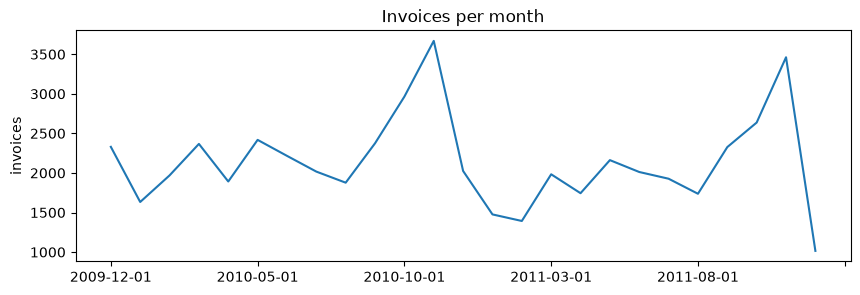

In [3]:
s = pd.Series(prof['invoices_per_month']); ax = s.plot(figsize=(10,3), title='Invoices per month')
ax.set_ylabel('invoices'); plt.show()

**Takeaways:** two sheets overlap on 2010-12-01…09 (removed by CR-00); 22.8% of lines have no Customer ID (15.2% of positive revenue); strong November peaks (Q4 seasonality).